# More regional cleanup arms: South Asia, Africa, North America + Europe (and the small arms)

`ks_gwl_1deg.ipynb` and `ks_regional_vs_ssp585.ipynb` tested only the East-Asia arm. RAMIP also ran
`ssp370-{SAS,AFR,NAE,ASIA}126aer` (all aerosol species reduced to SSP1-2.6 levels in one region) and
`ssp370-{SAF,SAS}126ca` (carbonaceous aerosol only). Same pipeline as the East-Asia arm, two anchors:

- **vs `ssp370`** — the arm against its own parent run (same run id), matched at GWL 2.0. Within one
  archive, so MIROC6 is valid here. CESM2's parent is `ssp370-LE`.
- **vs `ssp585`** — a genuinely different emissions pathway (ScenarioMIP), pairs formed within a
  `p<n>f<n>` variant. **MIROC6 excluded** (RAMIP MIROC6 is a different configuration, DATA.md §5).

Transform on the native grid → xESMF 1° → block-permutation KS (12-month blocks, 999 draws) →
land fraction and Wilks FDR (α_FDR = 0.2). Caches: `diagnostics/regional_arms/{anchor}_{arm}_{var}_{model}.nc`.

In [1]:
import os, re, warnings
os.environ.setdefault('ESMFMKFILE', '/burg-archive/home/mck2199/summer/.esmf/lib/esmf.mk')
import numpy as np
import pandas as pd
import xarray as xr

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RAMIP   = dir_list['raw'] + 'ramip/'
SCEN    = dir_list['raw'] + 'scenariomip/'
PRODUCT = dir_list['aux'] + 'gwl_timeseries.zarr'
GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
KS_DIR  = dir_list['aux'] + 'diagnostics/regional_arms/'
out_dir = dir_list['aux'] + '../figures/'
os.makedirs(KS_DIR, exist_ok=True)

GWL, ALPHA, FDR = 2.0, 0.05, 0.2
VARS = ['tas', 'pr', 'gdp']
ARMS = {'sas': 'ssp370-SAS126aer', 'afr': 'ssp370-AFR126aer', 'nae': 'ssp370-NAE126aer',
        'asia': 'ssp370-ASIA126aer', 'safca': 'ssp370-SAF126ca', 'sasca': 'ssp370-SAS126ca'}

# anchor 1: own ssp370 parent (RAMIP)
PARENT = {m: 'ssp370' for m in ['CanESM5-1', 'CNRM-ESM2-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G',
                                'MIROC6', 'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']}
PARENT['CESM2'] = 'ssp370-LE'
# anchor 2: ssp585 (ScenarioMIP model id -> RAMIP model id); MIROC6 invalid across archives
EXCLUDE_585 = ['MIROC6']
MODEL_MAP = {'CanESM5': 'CanESM5-1', 'CESM2': 'CESM2', 'CNRM-ESM2-1': 'CNRM-ESM2-1',
             'GISS-E2-1-G': 'GISS-E2-1-G', 'MRI-ESM2-0': 'MRI-ESM2-0', 'UKESM1-0-LL': 'UKESM1-0-LL'}

_gmst = xr.open_zarr(PRODUCT, group='gmst')
_gwl  = xr.open_zarr(PRODUCT, group='gwl')
win_df = pd.read_csv(f'{GWL_DIR}gwl{GWL}_windows.csv')


def gwl_ends(mod, exp):
    ids = _gmst.run_id.sel(model=mod, exp=exp).values
    we  = _gwl.window_end.sel(model=mod, exp=exp, gwl=GWL).values
    return {str(r): int(e) for r, e in zip(ids, we) if r and np.isfinite(e)}


def variant(run):
    return re.search(r'(p\d+f\d+)$', run).group(1)


def parent_pairs(mod, arm_exp):
    """(run, parent_end, run, arm_end): the arm against its own parent run, as ks_gwl_1deg does
    for the East-Asia arm. Parent windows come from the audited gwl2.0_windows.csv."""
    ends = gwl_ends(mod, arm_exp)
    rows = win_df[(win_df.model == mod) & win_df.usable]
    return [(r.run, int(r.anchor_end), r.run, ends[r.run]) for _, r in rows.iterrows() if r.run in ends]


def variant_pairs(mod_a, exp_a, mod_b, exp_b):
    """(run_a, end_a, run_b, end_b) formed within a p<n>f<n> variant, by sorted index"""
    a, b = gwl_ends(mod_a, exp_a), gwl_ends(mod_b, exp_b)
    by = lambda d: {v: sorted(r for r in d if variant(r) == v) for v in {variant(r) for r in d}}
    va, vb = by(a), by(b)
    out = []
    for v in sorted(set(va) & set(vb)):
        for ra, rb in zip(va[v], vb[v]):
            assert variant(ra) == variant(rb)
            out.append((ra, a[ra], rb, b[rb]))
    return out


# Optional subset for job-array runs: ARM=sas|afr|..., ANCHOR=370|585 (unset = everything).
# Caches are per (anchor, arm, var, model), so parallel subsets never write the same file.
ONLY_ARM, ONLY_ANCHOR = os.environ.get('ARM'), os.environ.get('ANCHOR')
if ONLY_ARM:
    ARMS = {ONLY_ARM: ARMS[ONLY_ARM]}

# JOBS[(anchor, arm, model)] = (anchor_root, anchor_model, anchor_exp, arm_model, pairs)
JOBS = {}
for arm, exp in ARMS.items():
    for m in PARENT:
        prs = parent_pairs(m, exp)
        if prs:
            JOBS[('370', arm, m)] = (RAMIP, m, PARENT[m], m, prs)
    for ms, mr in MODEL_MAP.items():
        prs = variant_pairs(ms, 'ssp585', mr, exp)
        if prs:
            JOBS[('585', arm, ms)] = (SCEN, ms, 'ssp585', mr, prs)
if ONLY_ANCHOR:
    JOBS = {k: v for k, v in JOBS.items() if k[0] == ONLY_ANCHOR}
print('subset:', ONLY_ARM or 'all arms', '/', ONLY_ANCHOR or 'both anchors')

summary = pd.DataFrame([{'anchor': k[0], 'arm': k[1], 'model': k[2], 'n_pairs': len(v[4]),
                         'mean_lead_yr': np.mean([ea - eb for _, ea, _, eb in v[4]])}
                        for k, v in JOBS.items()])
print(summary.pivot_table(index=['anchor', 'arm'], columns='model', values='n_pairs').fillna(0).astype(int).to_string())
print('total pair-tests:', int(summary.n_pairs.sum()) * len(VARS))
print('\nmean GWL-2.0 lead of the anchor over the arm (yr):')
print(summary.groupby(['anchor', 'arm']).mean_lead_yr.mean().round(1).to_string())

subset: all arms / both anchors
model         CESM2  CNRM-ESM2-1  CanESM5  CanESM5-1  EC-Earth3-AerChem  GISS-E2-1-G  MIROC6  MRI-ESM2-0  UKESM1-0-LL
anchor arm                                                                                                           
370    afr       10            1        0         10                  6           10      10           1           10
       asia       0            0        0          0                  0           10       6           0            0
       nae       10            1        0         10                  5           10      10          10           10
       safca      0            0        0          0                  0            9       1           0            0
       sas       10            0        0         10                  6           10      10           7            9
       sasca      0            1        0          0                  0            9       2           0            0
585    afr        3     

## KS on the common 1° grid (cached per anchor × arm × variable × model)

In [2]:
results = {}
for (anc, arm, mod), (aroot, amod, aexp, bmod, prs) in JOBS.items():
    for var in VARS:
        cache_fn = f'{KS_DIR}{anc}_{arm}_{var}_{mod}.nc'
        if os.path.exists(cache_fn):
            results[(anc, arm, var, mod)] = xr.open_dataset(cache_fn).load()
            continue
        src = kt.SRC_VAR.get(var, var)
        afns = kt.member_files(aroot, amod, aexp, src)
        bfns = kt.member_files(RAMIP, bmod, ARMS[arm], src)
        bp, asy, used = [], [], []
        for ra, ea, rb, eb in prs:
            if ra not in afns or rb not in bfns:
                print(f'  {anc} {arm} {var} {mod} {ra}/{rb}: no file, skipped'); continue
            out = kt.pair_ks_1deg(afns[ra], bfns[rb], var, ea, eb)
            if out is None:
                print(f'  {anc} {arm} {var} {mod} {ra}/{rb}: short window, skipped'); continue
            bp.append(out[0]); asy.append(out[1]); used.append(f'{ra}|{rb}')
        if not used:
            print(f'{anc} {arm} {var} {mod}: nothing usable'); continue
        dims = ('pair', 'lat', 'lon')
        ds = xr.Dataset({'p_blockperm': (dims, np.stack(bp).astype('float32')),
                         'p_asymptotic': (dims, np.stack(asy).astype('float32'))},
                        coords={'pair': used, 'lat': kt.GRID_OUT['lat'], 'lon': kt.GRID_OUT['lon']})
        ds.attrs.update(gwl=GWL, variable=var, anchor_exp=aexp, arm_exp=ARMS[arm],
                        anchor_model=amod, arm_model=bmod,
                        pairing='same run id' if anc == '370' else 'within p<n>f<n> variant, sorted index',
                        regrid=f"xESMF {kt.METHOD.get(var, 'bilinear')}, 1deg, transform-before-regrid")
        ds.to_netcdf(cache_fn)
        results[(anc, arm, var, mod)] = ds
        print(f'{anc} {arm} {var} {mod}: {len(used)} pairs -> {os.path.basename(cache_fn)}', flush=True)
print(len(results), 'maps ready')

153 maps ready


## Global land fractions: raw p<0.05 (floor 0.057) and Wilks FDR

In [3]:
rows = []
for (anc, arm, var, mod), ds in results.items():
    rows.append({'anchor': anc, 'arm': arm, 'var': var, 'model': mod, 'n_pairs': ds.sizes['pair'],
                 'raw': kt.land_fraction(ds, 'pair', ALPHA),
                 'fdr': kt.fdr_land_fraction(ds, 'pair', FDR)})
lf = pd.DataFrame(rows)
if not (ONLY_ARM or ONLY_ANCHOR):   # array tasks see a subset: only the full run writes tables
    lf.to_csv(f'{KS_DIR}land_fractions_global.csv', index=False)
ok = lf[~((lf.anchor == '585') & lf.model.isin(EXCLUDE_585))]
print(ok.pivot_table(index=['anchor', 'arm', 'model'], columns='var', values=['raw', 'fdr']).round(3).to_string())
print('\nmulti-model means (MIROC6 excluded from the ssp585 anchor):')
print(ok.groupby(['anchor', 'arm', 'var'])[['raw', 'fdr']].mean().unstack('var').round(3).to_string())

                                  fdr                raw              
var                               gdp   pr    tas    gdp     pr    tas
anchor arm   model                                                    
370    afr   CESM2              0.000  0.0  0.000  0.050  0.047  0.053
             CNRM-ESM2-1        0.000  0.0  0.000  0.038  0.039  0.041
             CanESM5-1          0.000  0.0  0.000  0.039  0.043  0.042
             EC-Earth3-AerChem  0.003  0.0  0.004  0.043  0.048  0.042
             GISS-E2-1-G        0.000  0.0  0.000  0.028  0.040  0.027
             MIROC6             0.001  0.0  0.001  0.042  0.040  0.044
             MRI-ESM2-0         0.000  0.0  0.000  0.058  0.071  0.058
             UKESM1-0-LL        0.000  0.0  0.000  0.055  0.052  0.058
       asia  GISS-E2-1-G        0.000  0.0  0.000  0.040  0.039  0.039
             MIROC6             0.000  0.0  0.003  0.058  0.047  0.062
       nae   CESM2              0.000  0.0  0.000  0.042  0.040  0.041
      

## Inside the cleanup region: the local fingerprint

A signal confined to the region where emissions were cut covers 1–5% of land, so the global land
fraction and an all-land FDR cannot see it. Here each map is split into land **inside** the arm's
RAMIP emission box (Wilcox et al. 2023, GMD 16, Tables 1–3) and land **outside** it, and the Wilks
FDR is applied **within the box only**. The in-box null comes from the 45 same-forcing CanESM5-1
member pairs regridded to the same 1° grid as the arms (`null_1deg_{var}.nc`, from
`method/audit/null1deg.py`), per variable, masked to the same box. A native-grid null is not comparable:
with p ≥ 1/1000 the FDR step-up needs ≥ 0.005·N pixels at the floor, i.e. 1 pixel in a 65-pixel native box
but 5 in a 1° box (AUDIT.md §3.5). The East-Asia arm is
included from the existing caches (`ks_1deg/eas_*` vs ssp370, `regional_vs_ssp585/eas_*` vs ssp585).

In [4]:
# RAMIP emission boxes: (lat_lo, lat_hi), (lon_lo, lon_hi) in degrees east, -180..180
BOXES = {
    'eas':   [((20, 53), (95, 133))],
    'sas':   [((5, 35), (65, 95))],
    'afr':   [((-35, 35), (-20, 60))],
    'nae':   [((35, 70), (-20, 45)), ((25, 70), (-150, -45))],
    'asia':  [((20, 53), (95, 133)), ((5, 35), (65, 95))],
    'safca': [((-35, 12), (-20, 50))],
    'sasca': [((5, 35), (65, 95))],
}


def box_mask(lat, lon, boxes):
    lon = np.asarray(lon)
    LA, LO = np.meshgrid(lat, np.where(lon > 180, lon - 360, lon), indexing='ij')
    m = np.zeros(LA.shape, bool)
    for (a, b), (c, d) in boxes:
        m |= (LA >= a) & (LA <= b) & (LO >= c) & (LO <= d)
    return m


def box_stats(ds, boxes, dim='pair'):
    p = ds['p_blockperm']
    land = kt.land_mask(ds.lat.values, ds.lon.values)
    box = box_mask(ds.lat.values, ds.lon.values, boxes) & land
    rej = (p < ALPHA).values
    pb = p.where(xr.DataArray(box, coords={'lat': ds.lat, 'lon': ds.lon}))
    fdr_in = float((kt.sig_fdr(pb, FDR) == 1).sum(('lat', 'lon')).mean(dim)) / box.sum()
    return {'n_box_px': int(box.sum()), 'in_box': rej[:, box].mean(),
            'outside': rej[:, land & ~box].mean(), 'fdr_in_box': fdr_in}


# null: same-forcing CanESM5-1 member pairs on the arms' 1deg grid (method/audit/null1deg.py), per variable,
# masked to each box; every rejection in these maps is a false positive
NULL = {}
for var in VARS:
    null_ds = xr.open_dataset(f'{KS_DIR}null_1deg_{var}.nc').load()
    for arm, b in BOXES.items():
        NULL[(arm, var)] = box_stats(null_ds, b)

# East-Asia arm from the earlier caches, so every arm sits in one table
eas_maps = {}
for anc, pat in [('370', GWL_DIR + 'ks_1deg/eas_{var}_{mod}.nc'),
                 ('585', dir_list['aux'] + 'diagnostics/regional_vs_ssp585/eas_{var}_{mod}.nc')]:
    for var in VARS:
        for mod in sorted(set(PARENT) | set(MODEL_MAP)):
            fn = pat.format(var=var, mod=mod)
            if os.path.exists(fn):
                ds = xr.open_dataset(fn).load()
                eas_maps[(anc, 'eas', var, mod)] = ds.rename({'run': 'pair'}) if 'run' in ds.dims else ds

rows = []
for (anc, arm, var, mod), ds in {**eas_maps, **results}.items():
    if anc == '585' and mod in EXCLUDE_585:
        continue
    rows.append({'anchor': anc, 'arm': arm, 'var': var, 'model': mod, 'n_pairs': ds.sizes['pair'],
                 **box_stats(ds, BOXES[arm])})
bx = pd.DataFrame(rows)
bx['ratio'] = bx.in_box / bx.outside
if not (ONLY_ARM or ONLY_ANCHOR):
    bx.to_csv(f'{KS_DIR}land_fractions_box.csv', index=False)

nul = pd.DataFrame(NULL).T[['n_box_px', 'in_box', 'fdr_in_box']].rename(
    columns={'in_box': 'null_in_box', 'fdr_in_box': 'null_fdr_in_box'})
nul.index.names = ['arm', 'var']
summ = (bx.groupby(['arm', 'anchor', 'var'])
          .agg(models=('model', 'nunique'), pairs=('n_pairs', 'sum'), in_box=('in_box', 'mean'),
               outside=('outside', 'mean'), ratio=('ratio', 'mean'), fdr_in_box=('fdr_in_box', 'mean'),
               models_fdr_pos=('fdr_in_box', lambda s: int((s > 0).sum())))
          .reset_index().merge(nul[['null_in_box', 'null_fdr_in_box']], left_on=['arm', 'var'], right_index=True))
if not (ONLY_ARM or ONLY_ANCHOR):
    summ.to_csv(f'{KS_DIR}box_summary.csv', index=False)
print('in-box null (45 same-forcing CanESM5-1 pairs, 1deg grid, per variable):')
print(nul.astype(float).round(3).to_string())
print('\nper arm x anchor x variable (multi-model mean; MIROC6 excluded vs ssp585):')
print(summ.round(3).to_string(index=False))

in-box null (45 same-forcing CanESM5-1 pairs, 1deg grid, per variable):
           n_box_px  null_in_box  null_fdr_in_box
arm   var                                        
eas   tas     987.0        0.059            0.019
sas   tas     501.0        0.029            0.000
afr   tas    2938.0        0.028            0.000
nae   tas    3703.0        0.050            0.005
asia  tas    1488.0        0.049            0.003
safca tas    1456.0        0.025            0.000
sasca tas     501.0        0.029            0.000
eas   pr      987.0        0.062            0.008
sas   pr      501.0        0.031            0.000
afr   pr     2938.0        0.036            0.000
nae   pr     3703.0        0.040            0.000
asia  pr     1488.0        0.051            0.003
safca pr     1456.0        0.035            0.000
sasca pr      501.0        0.031            0.000
eas   gdp     987.0        0.055            0.010
sas   gdp     501.0        0.038            0.000
afr   gdp    2938.0        0

## Figures

Same conventions as `ks_regional_vs_ssp585.ipynb`: rejection-frequency maps (fraction of pairs with
p < 0.05, `magma_r`, 0–0.3) and raw-vs-FDR land fractions against the 0.057 raw-count floor. The
East-Asia arm is drawn from its earlier caches so all seven arms sit side by side. MIROC6 is left out
of every ssp585 panel (DATA.md §5). Three figures:

1. `ks_regional_arms_landfrac.png` — global land fractions per arm, raw and Wilks FDR, per model.
2. `ks_regional_arms_fracmaps_{var}.png` — where the rejections fall, with the arm's RAMIP emission box outlined.
3. `ks_regional_arms_inbox.png` — the local test: rejection rate inside the box vs outside it (same maps)
   and vs the same-forcing CanESM5-1 null in the same box.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_arms_landfrac.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_arms_fracmaps_tas.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_arms_fracmaps_pr.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_arms_fracmaps_gdp.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_arms_inbox.png


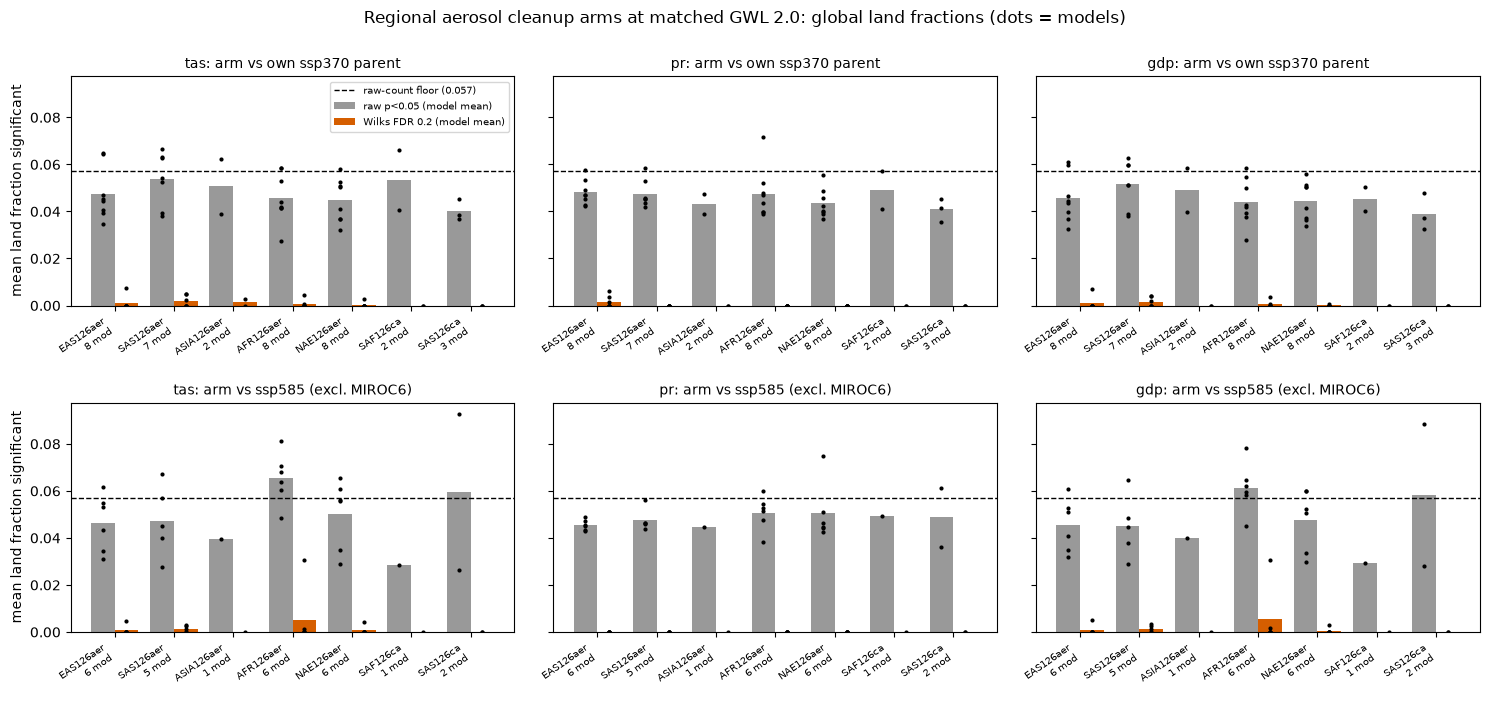

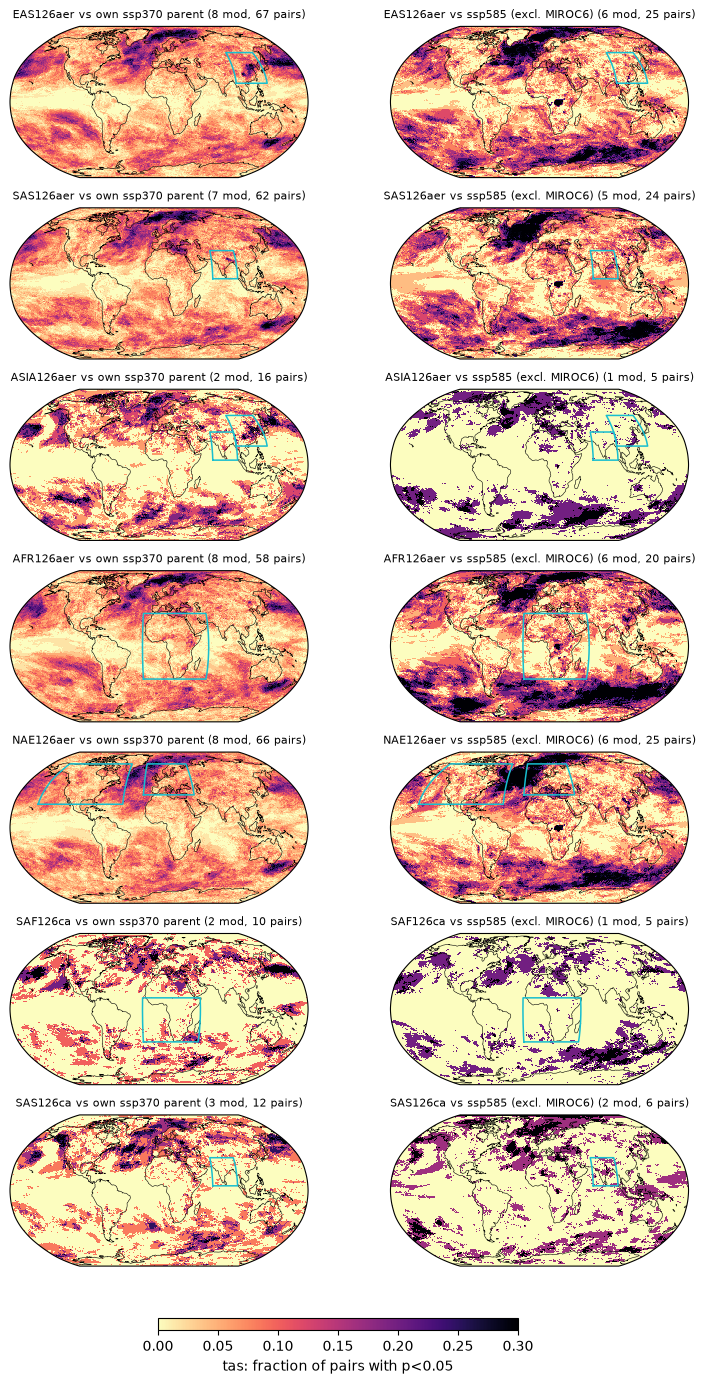

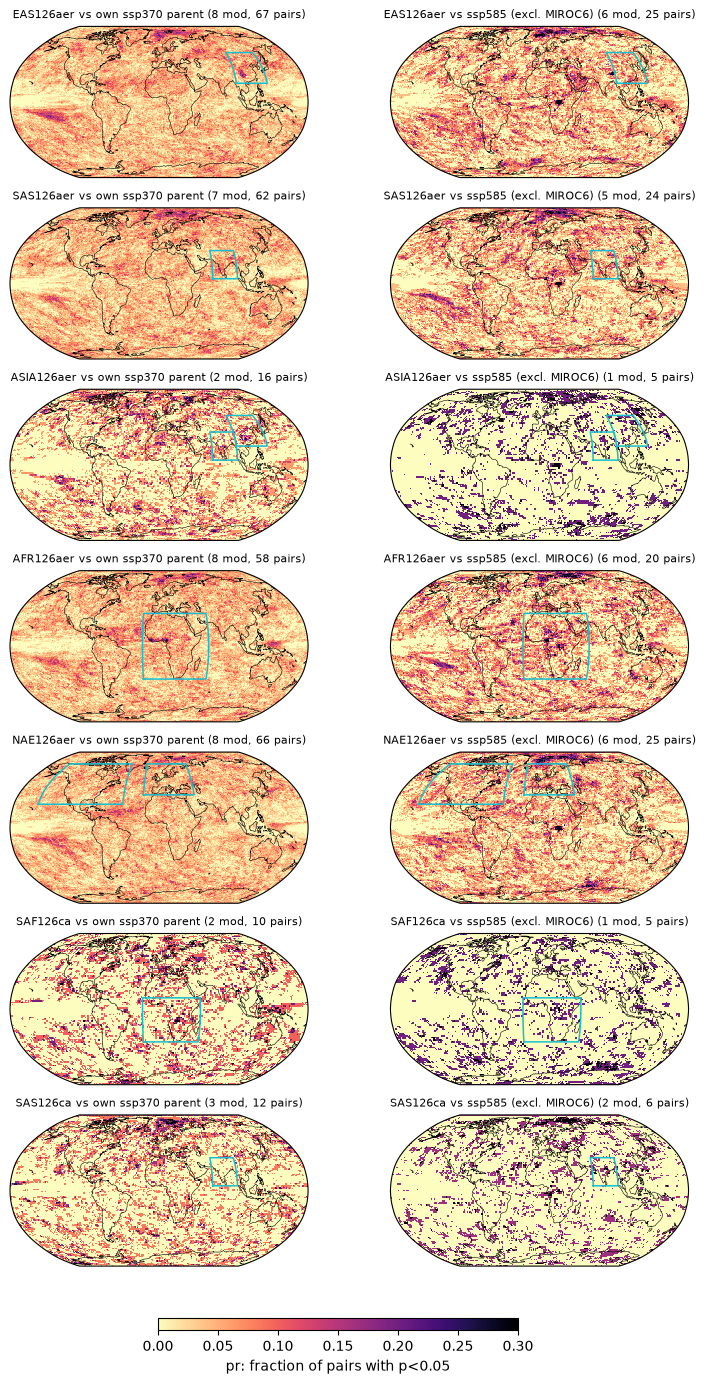

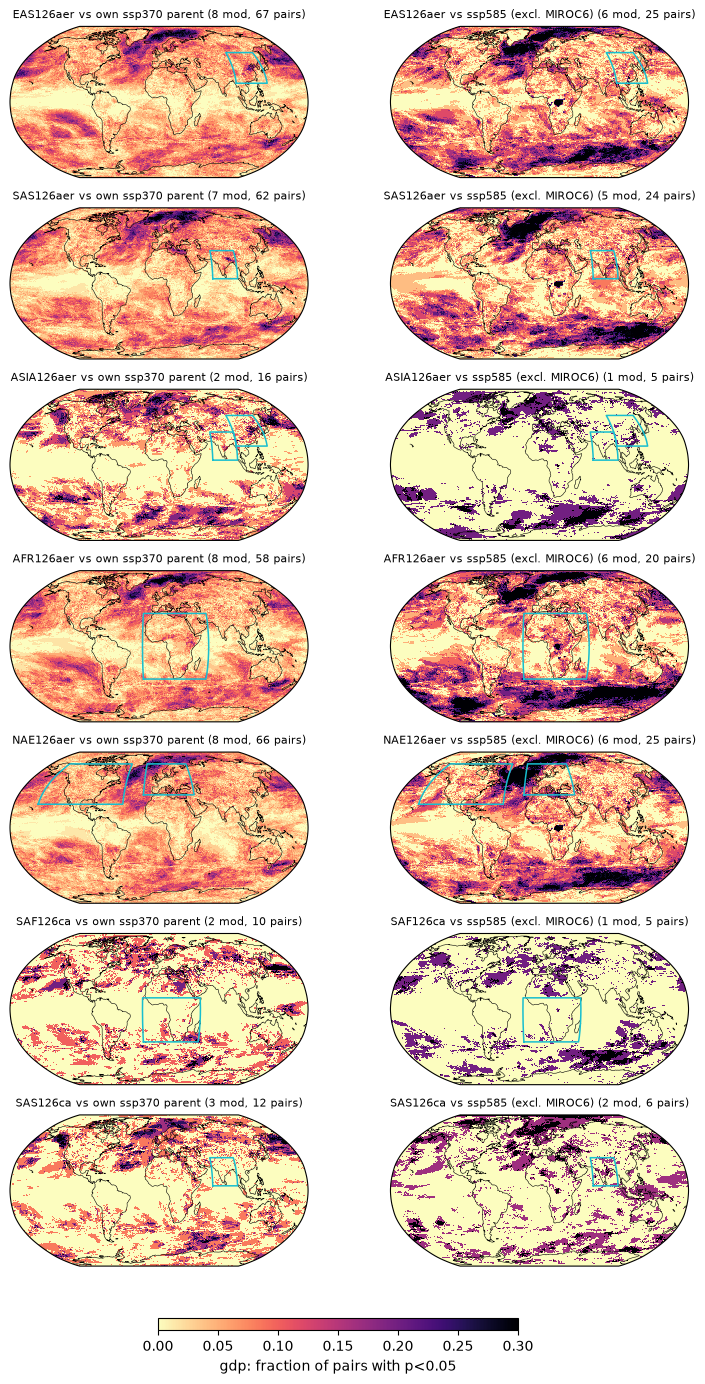

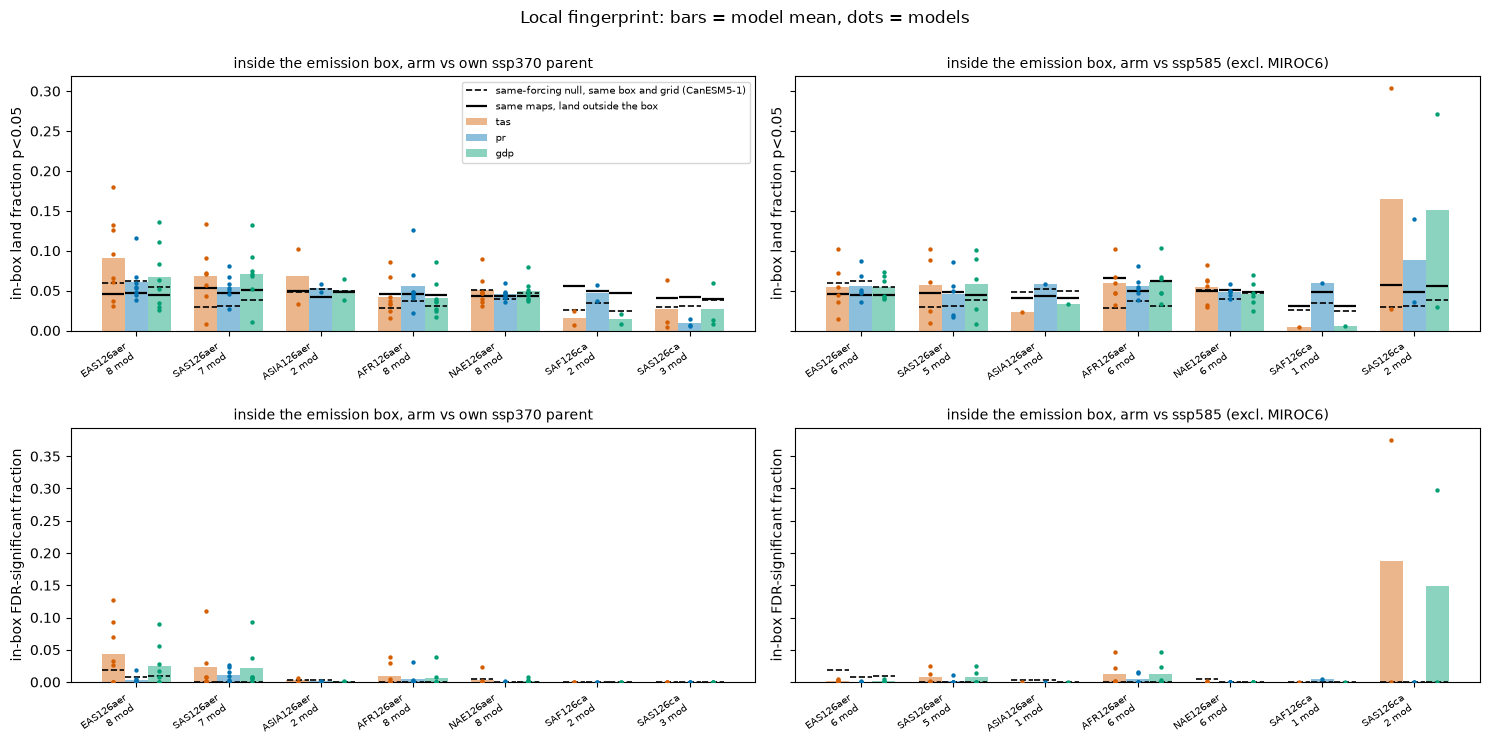

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

ARM_ORDER = ['eas', 'sas', 'asia', 'afr', 'nae', 'safca', 'sasca']
LABEL = {'eas': 'EAS126aer', 'sas': 'SAS126aer', 'asia': 'ASIA126aer', 'afr': 'AFR126aer',
         'nae': 'NAE126aer', 'safca': 'SAF126ca', 'sasca': 'SAS126ca'}
ANC_LABEL = {'370': 'vs own ssp370 parent', '585': 'vs ssp585 (excl. MIROC6)'}
VCOL = {'tas': '#d55e00', 'pr': '#0072b2', 'gdp': '#009e73'}
allmaps = {k: v for k, v in {**eas_maps, **results}.items()
           if k[2] in VARS and not (k[0] == '585' and k[3] in EXCLUDE_585)}

# --- figure 1: global land fractions, raw vs FDR, every arm (EAS from its earlier caches)
g = pd.DataFrame([{'anchor': anc, 'arm': arm, 'var': var, 'model': mod,
                   'raw': kt.land_fraction(ds, 'pair', ALPHA), 'fdr': kt.fdr_land_fraction(ds, 'pair', FDR)}
                  for (anc, arm, var, mod), ds in allmaps.items()])
fig, axs = plt.subplots(2, len(VARS), figsize=(15, 7), sharey=True)
x = np.arange(len(ARM_ORDER))
for row, anc in zip(axs, ['370', '585']):
    for ax, var in zip(row, VARS):
        d = g[(g.anchor == anc) & (g['var'] == var)]
        m = d.groupby('arm')[['raw', 'fdr']].mean().reindex(ARM_ORDER)
        ax.bar(x - 0.2, m.raw, 0.4, color='0.6', label='raw p<0.05 (model mean)')
        ax.bar(x + 0.2, m.fdr, 0.4, color='#d55e00', label='Wilks FDR 0.2 (model mean)')
        for a, arm in enumerate(ARM_ORDER):
            dd = d[d.arm == arm]
            ax.scatter(np.full(len(dd), a - 0.2), dd.raw, s=9, color='k', zorder=3, lw=0)
            ax.scatter(np.full(len(dd), a + 0.2), dd.fdr, s=9, color='k', zorder=3, lw=0)
        ax.axhline(0.057, color='k', ls='--', lw=1, label='raw-count floor (0.057)')
        ax.set_xticks(x, [f'{LABEL[a]}\n{d[d.arm == a].model.nunique()} mod' for a in ARM_ORDER],
                      rotation=35, ha='right', fontsize=7.5)
        ax.set_title(f'{var}: arm {ANC_LABEL[anc]}', fontsize=10)
    row[0].set_ylabel('mean land fraction significant')
axs[0, 0].legend(fontsize=7.5, loc='upper right')
fig.suptitle(f'Regional aerosol cleanup arms at matched GWL {GWL}: global land fractions (dots = models)', y=1.0)
fig.tight_layout()
fig.savefig(out_dir + 'ks_regional_arms_landfrac.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_regional_arms_landfrac.png')


# --- figure 2: rejection-frequency maps, every arm x anchor, emission box outlined (one figure per var)
def draw_boxes(ax, boxes):
    for (a, b), (c, d) in boxes:
        t = np.linspace(0, 1, 40)
        lo = np.r_[c + (d - c) * t, np.full(40, d), d - (d - c) * t, np.full(40, c)]
        la = np.r_[np.full(40, a), a + (b - a) * t, np.full(40, b), b - (b - a) * t]
        ax.plot(lo, la, color='tab:cyan', lw=1.1, transform=ccrs.PlateCarree())


for var in VARS:
    fig, axs = plt.subplots(len(ARM_ORDER), 2, figsize=(9, 2.3 * len(ARM_ORDER)),
                            subplot_kw={'projection': ccrs.Robinson()})
    for r, arm in enumerate(ARM_ORDER):
        for c, anc in enumerate(['370', '585']):
            ax = axs[r, c]
            ax.coastlines(lw=0.4)
            ps = [v.p_blockperm.transpose('pair', 'lat', 'lon').values
                  for k, v in allmaps.items() if k[:3] == (anc, arm, var)]
            if not ps:
                ax.set_title(f'{LABEL[arm]} {ANC_LABEL[anc]}: no pairs', fontsize=8)
                continue
            p = np.concatenate(ps)
            assert p.shape[1:] == (kt.NLAT, kt.NLON)
            im = ax.pcolormesh(kt.GRID_OUT['lon'], kt.GRID_OUT['lat'], (p < ALPHA).mean(0), cmap='magma_r',
                               vmin=0, vmax=0.3, transform=ccrs.PlateCarree())
            draw_boxes(ax, BOXES[arm])
            ax.set_title(f'{LABEL[arm]} {ANC_LABEL[anc]} ({len(ps)} mod, {p.shape[0]} pairs)', fontsize=8)
    cax = fig.add_axes([0.3, 0.07, 0.4, 0.008])
    fig.colorbar(im, cax=cax, orientation='horizontal', label=f'{var}: fraction of pairs with p<{ALPHA}')
    fn = out_dir + f'ks_regional_arms_fracmaps_{var}.png'
    fig.savefig(fn, dpi=150, bbox_inches='tight')
    print('saved', fn)

# --- figure 3: the local test. Inside the emission box vs outside it (same maps) vs the box null
fig, axs = plt.subplots(2, 2, figsize=(15, 7.5), sharey='row')
for c, anc in enumerate(['370', '585']):
    for r, (col, ncol, ylab) in enumerate([('in_box', 'null_in_box', f'in-box land fraction p<{ALPHA}'),
                                           ('fdr_in_box', 'null_fdr_in_box', 'in-box FDR-significant fraction')]):
        ax = axs[r, c]
        for k, var in enumerate(VARS):
            off = (k - 1) * 0.25
            for a, arm in enumerate(ARM_ORDER):
                d = bx[(bx.anchor == anc) & (bx.arm == arm) & (bx['var'] == var)]
                if d.empty:
                    continue
                ax.bar(a + off, d[col].mean(), 0.25, color=VCOL[var], alpha=0.45,
                       label=var if a == 0 or (arm == 'sas' and anc == '585') else None)
                ax.scatter(np.full(len(d), a + off), d[col], s=10, color=VCOL[var], zorder=3, lw=0)
                ax.hlines(nul.loc[(arm, var), ncol], a + off - 0.12, a + off + 0.12, color='k', ls='--', lw=1.2,
                          label='same-forcing null, same box and grid (CanESM5-1)' if (a, k) == (0, 0) else None)
                if r == 0:
                    ax.hlines(d.outside.mean(), a + off - 0.12, a + off + 0.12, color='k', lw=1.6,
                              label='same maps, land outside the box' if (a, k) == (0, 0) else None)
        ax.set_xticks(x, [f"{LABEL[a]}\n{bx[(bx.anchor == anc) & (bx.arm == a)].model.nunique()} mod"
                          for a in ARM_ORDER], rotation=35, ha='right', fontsize=7.5)
        ax.set_ylabel(ylab)
        ax.set_title(f'inside the emission box, arm {ANC_LABEL[anc]}', fontsize=10)
handles, labels = axs[0, 0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axs[0, 0].legend(uniq.values(), uniq.keys(), fontsize=7.5, loc='upper right')
fig.suptitle('Local fingerprint: bars = model mean, dots = models', y=1.0)
fig.tight_layout()
fig.savefig(out_dir + 'ks_regional_arms_inbox.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_regional_arms_inbox.png')

## Reading the results (see `AUDIT.md` for the validation behind each statement)

**Global (land): no detectable path dependence for any regional arm.** Raw land fractions sit at or below the
0.057 raw-count floor and Wilks FDR is ≤ 0.005 in every multi-model mean, for both anchors and all three variables.
This is a detection limit, not a demonstration of independence: the per-pixel test needs an imposed shift of
~1 K in monthly `tas` (~25 % in monthly `pr`) to reject at half the land pixels, while the regional cleanups
change in-box means by ≤ 0.25 K and ≤ 4 % even at full emission divergence (AUDIT.md §3.1–3.2).

**Local: a small, real fingerprint where the emissions were cut.** EAS126aer `tas`: 9.1 % of box land rejected
vs 4.6 % outside on the same maps, in-box FDR above the same-grid null in 5/8 models; SAS126aer in 6/7 models.
Box-mean effect sizes at matched GWL: EAS +0.14 K, SAS +0.10 K, +2–4 % precipitation; other land ~0. A test on
the box-mean monthly-anomaly series (AUDIT.md §3.4) rejects for EAS/ASIA temperature and AFR/ASIA/SAS
precipitation at 4–8× its null — the pathways do differ at 2 °C, by about that much. NAE126aer and the
carbonaceous-only arms show nothing even at the box scale.

**Timing confound.** The matched 2 °C decade ends in 2027 for CanESM5-1 but 2065 for MIROC6; hot models are
tested before the aerosol pathways have separated, and the in-box response grows with the window year
(AUDIT.md §3.3). The multi-model mean mixes the two regimes.

**Against ssp585 the local signal weakens** (EAS ≈ 0.001, SAS ≈ 0.008 FDR): fewer pairs (≤ 25) and SSP5's own
air-quality controls make its regional aerosol burden closer to the cleaned arm's than `ssp370`'s is.

**Not evidence:** SAS126ca vs ssp585 (FDR 0.15–0.19) is one CNRM-ESM2-1 pair; SAF126ca/SAS126ca in-box
rejections are *below* the null. The dark patch over the Congo basin in every ssp585 map is on the ssp585 side
(it appears in `ks_regional_vs_ssp585_fracmaps.png` too) and has not been traced. The dark ocean areas
(subpolar North Atlantic, Southern Ocean) are mostly the test's own ocean false-positive rate: 0.082 vs 0.046 on
land for same-forcing pairs, because 12-month blocks do not carry multi-year SST memory.

**FDR resolution.** With 999 draws the step-up needs ≥ 0.005·N pixels at the p = 0.001 floor (108 pixels over
1° land), so "FDR ≈ 0" means "fewer than 108 land pixels at the floor"; the in-box null above is on the same
1° grid for that reason.